# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it. 

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16). 
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook. 

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

6. Implement a new player with the following strategy:

    * Assign each card a value: 
        * Cards 2 to 6 are +1 
        * Cards 7 to 9 are 0 
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  

7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.

8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?


9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings. 

In [8]:

from __future__ import annotations
from dataclasses import dataclass, field
from typing import List, Optional, Dict, Any
import random
import math

RANKS = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "J", "Q", "K", "A"]
SUITS = ["Hearts", "Diamonds", "Clubs", "Spades"]
CARD_COUNT_VALUES = {
    "2": 1, "3": 1, "4": 1, "5": 1, "6": 1,
    "7": 0, "8": 0, "9": 0,
    "10": -1, "J": -1, "Q": -1, "K": -1, "A": -1
}

@dataclass(frozen=True)
class Card:
    rank: str
    suit: str

    @property
    def value(self) -> int:
        if self.rank == "A":
            return 11
        if self.rank in {"J", "Q", "K"}:
            return 10
        return int(self.rank)

    @property
    def count_value(self) -> int:
        return CARD_COUNT_VALUES[self.rank]

    def __str__(self) -> str:
        return f"{self.rank} of {self.suit}"


class Shoe:
    def __init__(self, num_decks: int = 6, penetration: float = 0.75, rng: Optional[random.Random] = None):
        self.num_decks = num_decks
        self.penetration = penetration
        self.rng = rng or random.Random()
        self.cards: List[Card] = []
        self.discard_pile: List[Card] = []
        self.cut_index: int = 0
        self.cut_reached: bool = False
        self.shuffle()

    def _build_cards(self) -> List[Card]:
        return [Card(rank, suit) for _ in range(self.num_decks) for suit in SUITS for rank in RANKS]

    def shuffle(self) -> None:
        self.cards = self._build_cards()
        self.rng.shuffle(self.cards)
        total = len(self.cards)
        low = int(total * self.penetration)
        high = min(total - 1, low + max(1, int(0.08 * total)))
        self.cut_index = self.rng.randint(low, high)
        self.cut_reached = False
        self.discard_pile = []

    def draw(self) -> Card:
        if not self.cards:
            self.shuffle()
        dealt_so_far = self.total_cards - len(self.cards)
        if dealt_so_far >= self.cut_index:
            self.cut_reached = True
        card = self.cards.pop()
        self.discard_pile.append(card)
        return card

    @property
    def cards_remaining(self) -> int:
        return len(self.cards)

    @property
    def total_cards(self) -> int:
        return self.num_decks * 52

    @property
    def decks_remaining(self) -> float:
        return max(len(self.cards) / 52.0, 0.25)


class Hand:
    def __init__(self) -> None:
        self.cards: List[Card] = []

    def add_card(self, card: Card) -> None:
        self.cards.append(card)

    @property
    def total(self) -> int:
        total = sum(c.value for c in self.cards)
        aces = sum(1 for c in self.cards if c.rank == "A")
        while total > 21 and aces > 0:
            total -= 10
            aces -= 1
        return total

    @property
    def is_soft(self) -> bool:
        hard_total = sum(1 if c.rank == "A" else c.value for c in self.cards)
        return any(c.rank == "A" for c in self.cards) and hard_total + 10 == self.total

    @property
    def is_blackjack(self) -> bool:
        return len(self.cards) == 2 and self.total == 21

    @property
    def is_bust(self) -> bool:
        return self.total > 21

    def reset(self) -> None:
        self.cards = []

    def __str__(self) -> str:
        return f"{', '.join(str(c) for c in self.cards)} (total={self.total})"


class TableObserver:
    def __init__(self) -> None:
        self.running_count = 0
        self.seen_cards: List[Card] = []

    def see_card(self, card: Card) -> None:
        self.seen_cards.append(card)
        self.running_count += card.count_value

    def reset(self) -> None:
        self.running_count = 0
        self.seen_cards = []

    def true_count(self, shoe: Shoe) -> float:
        return self.running_count / shoe.decks_remaining


class Player:
    def __init__(self, name: str, chips: int = 100, base_bet: int = 10):
        self.name = name
        self.chips = chips
        self.base_bet = base_bet
        self.hand = Hand()
        self.current_bet = base_bet
        self.hands_played = 0

    def reset_hand(self) -> None:
        self.hand.reset()
        self.current_bet = self.base_bet

    def can_bet(self) -> bool:
        return self.chips >= self.base_bet

    def place_bet(self) -> int:
        bet = min(self.base_bet, self.chips)
        self.current_bet = bet
        return bet

    def decide_hit(self, dealer_upcard: Card, table: TableObserver, shoe: Shoe) -> bool:
        raise NotImplementedError

    def settle_win(self, blackjack: bool = False) -> None:
        payout = int(1.5 * self.current_bet) if blackjack else self.current_bet
        self.chips += payout

    def settle_loss(self) -> None:
        self.chips -= self.current_bet

    def settle_push(self) -> None:
        pass


class Dealer(Player):
    def __init__(self, name: str = "Dealer"):
        super().__init__(name=name, chips=10**9, base_bet=0)

    def place_bet(self) -> int:
        return 0

    def decide_hit(self, dealer_upcard: Card, table: TableObserver, shoe: Shoe) -> bool:
        if self.hand.total < 17:
            return True
        if self.hand.total == 17 and self.hand.is_soft:
            return False   # stand on soft 17
        return False


class DealerStylePlayer(Player):
    def decide_hit(self, dealer_upcard: Card, table: TableObserver, shoe: Shoe) -> bool:
        if self.hand.total < 17:
            return True
        if self.hand.total == 17 and self.hand.is_soft:
            return False
        return False



class BasicStrategyPlayer(Player):
    def decide_hit(self, dealer_upcard: Card, table: TableObserver, shoe: Shoe) -> bool:
        total = self.hand.total
        up = dealer_upcard.value
        if total <= 11:
            return True
        if total >= 17:
            return False
        if total == 12:
            return up not in {4, 5, 6}
        if 13 <= total <= 16:
            return up not in {2, 3, 4, 5, 6}
        return False


class HumanPlayer(Player):
    def decide_hit(self, dealer_upcard: Card, table: TableObserver, shoe: Shoe) -> bool:
        while True:
            choice = input(
                f"{self.name}: your hand is {self.hand}. Dealer shows {dealer_upcard}. Hit or stay? [h/s]: "
            ).strip().lower()
            if choice in {"h", "hit"}:
                return True
            if choice in {"s", "stay", "stand"}:
                return False
            print("Please enter h or s.")


class CountThresholdPlayer(Player):
    def __init__(self, name: str, chips: int = 100, base_bet: int = 10, threshold: float = 0.0):
        super().__init__(name=name, chips=chips, base_bet=base_bet)
        self.threshold = threshold

    def decide_hit(self, dealer_upcard: Card, table: TableObserver, shoe: Shoe) -> bool:
        if self.hand.total >= 21:
            return False
        if self.hand.total <= 11:
            return True
        if self.hand.total >= 17:
            return False
        count = table.running_count
        return count <= self.threshold


class TrueCountBettingPlayer(Player):
    """
    Strategy idea: use a conservative total-based hit rule, but vary bet size using true count.
    This is closer to real card counting usage than changing hit/stay only.
    """
    def __init__(self, name: str, chips: int = 100, base_bet: int = 10,
                 ramp: Optional[Dict[int, int]] = None):
        super().__init__(name=name, chips=chips, base_bet=base_bet)
        self.ramp = ramp or {0: 1, 2: 2, 3: 4, 4: 6}

    def place_bet_with_context(self, table: TableObserver, shoe: Shoe) -> int:
        tc = math.floor(table.true_count(shoe))
        multiplier = 1
        for k in sorted(self.ramp):
            if tc >= k:
                multiplier = self.ramp[k]
        bet = min(self.base_bet * multiplier, self.chips)
        self.current_bet = max(1, bet)
        return self.current_bet

    def place_bet(self) -> int:
        return min(self.base_bet, self.chips)

    def decide_hit(self, dealer_upcard: Card, table: TableObserver, shoe: Shoe) -> bool:
        total = self.hand.total
        if total <= 11:
            return True
        if total >= 17:
            return False
        if total == 12:
            return dealer_upcard.value not in {4, 5, 6}
        if 13 <= total <= 16:
            return dealer_upcard.value not in {2, 3, 4, 5, 6}
        return False


class BlackjackGame:
    def __init__(self, players: List[Player], num_decks: int = 6, starting_chips: int = 100,
                 base_bet: int = 10, penetration: float = 0.75,
                 rng_seed: Optional[int] = None, verbose: bool = True):
        self.rng = random.Random(rng_seed)
        self.shoe = Shoe(num_decks=num_decks, penetration=penetration, rng=self.rng)
        self.table = TableObserver()
        self.players = players
        self.dealer = Dealer()
        self.verbose = verbose
        self.round_number = 0

        for p in self.players:
            p.chips = starting_chips
            p.base_bet = base_bet

    def _print(self, *args: Any, **kwargs: Any) -> None:
        if self.verbose:
            print(*args, **kwargs)

    def _reveal(self, card: Card) -> None:
        self.table.see_card(card)

    def _deal_card(self, hand: Hand, face_up: bool = True) -> Card:
        card = self.shoe.draw()
        hand.add_card(card)
        if face_up:
            self._reveal(card)
        return card

    def _all_active_players(self) -> List[Player]:
        return [p for p in self.players if p.can_bet()]

    def _bets(self) -> Dict[str, int]:
        bets = {}
        for p in self._all_active_players():
            if isinstance(p, TrueCountBettingPlayer):
                bets[p.name] = p.place_bet_with_context(self.table, self.shoe)
            else:
                bets[p.name] = p.place_bet()
        return bets

    def play_round(self) -> Dict[str, Any]:
        if self.shoe.cut_reached:
            self._print("\nCut card reached - shuffling before next round.\n")
            self.shoe.shuffle()
            self.table.reset()

        active_players = self._all_active_players()
        if not active_players:
            return {"status": "no_players"}

        self.round_number += 1
        self._print(f"\n=== Round {self.round_number} ===")
        self._print("Running count before betting:", self.table.running_count)

        # Reset hands
        self.dealer.reset_hand()
        for p in self.players:
            p.reset_hand()

        bets = self._bets()

        # Initial deal
        for p in active_players:
            self._deal_card(p.hand, face_up=True)
        dealer_up = self._deal_card(self.dealer.hand, face_up=True)
        for p in active_players:
            self._deal_card(p.hand, face_up=True)
        self._deal_card(self.dealer.hand, face_up=False)  # hole card hidden until reveal

        self._print(f"Dealer shows: {dealer_up}")
        for p in active_players:
            self._print(f"{p.name}: {p.hand} | bet={bets[p.name]} | chips={p.chips}")

        # Reveal dealer hole card for blackjack check / later actions
        dealer_hole = self.dealer.hand.cards[1]
        self._reveal(dealer_hole)

        results: Dict[str, str] = {}

        # Natural blackjacks
        dealer_has_bj = self.dealer.hand.is_blackjack
        if dealer_has_bj:
            self._print(f"Dealer blackjack! Hole card was {dealer_hole}.")
            for p in active_players:
                if p.hand.is_blackjack:
                    results[p.name] = "push"
                else:
                    p.settle_loss()
                    results[p.name] = "loss"
            return {
                "status": "completed",
                "results": results,
                "running_count": self.table.running_count
            }

        for p in active_players:
            if p.hand.is_blackjack:
                p.settle_win(blackjack=True)
                results[p.name] = "blackjack"

        # Players play
        for p in active_players:
            if p.name in results:
                continue
            while not p.hand.is_bust and p.decide_hit(dealer_up, self.table, self.shoe):
                card = self._deal_card(p.hand, face_up=True)
                self._print(f"{p.name} hits and receives {card}. Total = {p.hand.total}")
            if p.hand.is_bust:
                p.settle_loss()
                results[p.name] = "bust"
                self._print(f"{p.name} busts with {p.hand.total}.")
            else:
                self._print(f"{p.name} stays on {p.hand.total}.")

        # Dealer plays against non-busted players
        live_players = [p for p in active_players if results.get(p.name) not in {"bust", "loss", "blackjack"}]
        if live_players:
            self._print(f"Dealer hole card: {dealer_hole}. Dealer total = {self.dealer.hand.total}")
            while self.dealer.decide_hit(dealer_up, self.table, self.shoe):
                card = self._deal_card(self.dealer.hand, face_up=True)
                self._print(f"Dealer hits {card}. Total = {self.dealer.hand.total}")

        # Settle
        dealer_total = self.dealer.hand.total
        dealer_bust = self.dealer.hand.is_bust
        if dealer_bust:
            self._print(f"Dealer busts with {dealer_total}.")
        else:
            self._print(f"Dealer stays on {dealer_total}.")

        for p in active_players:
            if p.name in results:
                continue
            player_total = p.hand.total
            if dealer_bust or player_total > dealer_total:
                p.settle_win()
                results[p.name] = "win"
            elif player_total < dealer_total:
                p.settle_loss()
                results[p.name] = "loss"
            else:
                p.settle_push()
                results[p.name] = "push"

        for p in active_players:
            p.hands_played += 1
            self._print(f"{p.name}: {results[p.name]} | chips={p.chips}")

        return {
            "status": "completed",
            "results": results,
            "dealer_total": dealer_total,
            "running_count": self.table.running_count,
            "shoe_cards_remaining": self.shoe.cards_remaining
        }

    def play_many_rounds(self, rounds: int = 10) -> List[Dict[str, Any]]:
        history = []
        for _ in range(rounds):
            if not self._all_active_players():
                break
            history.append(self.play_round())
        return history


def run_threshold_experiment(
    threshold: float,
    games: int = 100,
    rounds_per_game: int = 50,
    starting_chips: int = 200,
    base_bet: int = 10,
    num_decks: int = 6,
    seed: int = 1234
) -> Dict[str, Any]:
    final_chips = []
    for g in range(games):
        players = [
            CountThresholdPlayer("Counter", chips=starting_chips, base_bet=base_bet, threshold=threshold),
            DealerStylePlayer("P2", chips=starting_chips, base_bet=base_bet),
            DealerStylePlayer("P3", chips=starting_chips, base_bet=base_bet),
            DealerStylePlayer("P4", chips=starting_chips, base_bet=base_bet),
        ]
        game = BlackjackGame(
            players=players,
            num_decks=num_decks,
            starting_chips=starting_chips,
            base_bet=base_bet,
            rng_seed=seed + g,
            verbose=False
        )
        for _ in range(rounds_per_game):
            if not players[0].can_bet():
                break
            game.play_round()
        final_chips.append(players[0].chips)

    mean_final = sum(final_chips) / len(final_chips)
    winnings = [x - starting_chips for x in final_chips]
    avg_per_round = sum(winnings) / (len(winnings) * rounds_per_game)
    std_final = (sum((x - mean_final) ** 2 for x in final_chips) / (len(final_chips) - 1)) ** 0.5 if len(final_chips) > 1 else 0.0
    p_win = sum(1 for x in final_chips if x > starting_chips) / len(final_chips)
    p_loss = sum(1 for x in final_chips if x < starting_chips) / len(final_chips)
    p_even = sum(1 for x in final_chips if x == starting_chips) / len(final_chips)
    return {
        "threshold": threshold,
        "final_chips": final_chips,
        "winnings": winnings,
        "average_final_chips": mean_final,
        "average_winnings_per_round": avg_per_round,
        "std_final_chips": std_final,
        "prob_net_win": p_win,
        "prob_net_loss": p_loss,
        "prob_break_even": p_even,
    }


def run_betting_strategy_experiment(
    games: int = 100,
    rounds_per_game: int = 50,
    starting_chips: int = 200,
    base_bet: int = 10,
    num_decks: int = 6,
    seed: int = 4321
) -> Dict[str, Any]:
    final_chips = []
    for g in range(games):
        players = [
            TrueCountBettingPlayer("TrueCountBetter", chips=starting_chips, base_bet=base_bet),
            DealerStylePlayer("P2", chips=starting_chips, base_bet=base_bet),
            DealerStylePlayer("P3", chips=starting_chips, base_bet=base_bet),
            DealerStylePlayer("P4", chips=starting_chips, base_bet=base_bet),
        ]
        game = BlackjackGame(
            players=players,
            num_decks=num_decks,
            starting_chips=starting_chips,
            base_bet=base_bet,
            rng_seed=seed + g,
            verbose=False
        )
        for _ in range(rounds_per_game):
            if not players[0].can_bet():
                break
            game.play_round()
        final_chips.append(players[0].chips)

    mean_final = sum(final_chips) / len(final_chips)
    winnings = [x - starting_chips for x in final_chips]
    avg_per_round = sum(winnings) / (len(winnings) * rounds_per_game)
    std_final = (sum((x - mean_final) ** 2 for x in final_chips) / (len(final_chips) - 1)) ** 0.5 if len(final_chips) > 1 else 0.0
    p_win = sum(1 for x in final_chips if x > starting_chips) / len(final_chips)
    p_loss = sum(1 for x in final_chips if x < starting_chips) / len(final_chips)
    p_even = sum(1 for x in final_chips if x == starting_chips) / len(final_chips)
    return {
        "final_chips": final_chips,
        "winnings": winnings,
        "average_final_chips": mean_final,
        "average_winnings_per_round": avg_per_round,
        "std_final_chips": std_final,
        "prob_net_win": p_win,
        "prob_net_loss": p_loss,
        "prob_break_even": p_even,
    }

def run_basic_strategy_experiment(
    games: int = 100,
    rounds_per_game: int = 50,
    starting_chips: int = 200,
    base_bet: int = 10,
    num_decks: int = 6,
    seed: int = 2468
) -> Dict[str, Any]:
    final_chips = []
    for g in range(games):
        players = [
            BasicStrategyPlayer("Basic", chips=starting_chips, base_bet=base_bet),
            DealerStylePlayer("P2", chips=starting_chips, base_bet=base_bet),
            DealerStylePlayer("P3", chips=starting_chips, base_bet=base_bet),
            DealerStylePlayer("P4", chips=starting_chips, base_bet=base_bet),
        ]
        game = BlackjackGame(
            players=players,
            num_decks=num_decks,
            starting_chips=starting_chips,
            base_bet=base_bet,
            rng_seed=seed + g,
            verbose=False
        )
        for _ in range(rounds_per_game):
            if not players[0].can_bet():
                break
            game.play_round()
        final_chips.append(players[0].chips)

    mean_final = sum(final_chips) / len(final_chips)
    winnings = [x - starting_chips for x in final_chips]
    avg_per_round = sum(winnings) / (len(winnings) * rounds_per_game)
    std_final = (sum((x - mean_final) ** 2 for x in final_chips) / (len(final_chips) - 1)) ** 0.5 if len(final_chips) > 1 else 0.0
    p_win = sum(1 for x in final_chips if x > starting_chips) / len(final_chips)
    p_loss = sum(1 for x in final_chips if x < starting_chips) / len(final_chips)
    p_even = sum(1 for x in final_chips if x == starting_chips) / len(final_chips)
    return {
        "final_chips": final_chips,
        "winnings": winnings,
        "average_final_chips": mean_final,
        "average_winnings_per_round": avg_per_round,
        "std_final_chips": std_final,
        "prob_net_win": p_win,
        "prob_net_loss": p_loss,
        "prob_break_even": p_even,
    }


In [10]:
#Demonstration of gameplay
demo_players = [
    DealerStylePlayer("P1", chips=100, base_bet=10),
    DealerStylePlayer("P2", chips=100, base_bet=10),
    DealerStylePlayer("P3", chips=100, base_bet=10),
]

demo_game = BlackjackGame(demo_players, rng_seed=42, verbose=True)
demo_history = demo_game.play_many_rounds(3)

print("\nEnding chips:")
for p in demo_players:
    print(p.name, p.chips)


=== Round 1 ===
Running count before betting: 0
Dealer shows: 10 of Diamonds
P1: 7 of Hearts, Q of Hearts (total=17) | bet=10 | chips=100
P2: A of Hearts, 8 of Diamonds (total=19) | bet=10 | chips=100
P3: Q of Clubs, 2 of Hearts (total=12) | bet=10 | chips=100
P1 stays on 17.
P2 stays on 19.
P3 hits and receives 7 of Spades. Total = 19
P3 stays on 19.
Dealer hole card: 8 of Diamonds. Dealer total = 18
Dealer stays on 18.
P1: loss | chips=90
P2: win | chips=110
P3: win | chips=110

=== Round 2 ===
Running count before betting: -3
Dealer shows: 4 of Diamonds
P1: 5 of Spades, 10 of Spades (total=15) | bet=10 | chips=90
P2: 10 of Hearts, 9 of Hearts (total=19) | bet=10 | chips=110
P3: 5 of Diamonds, 4 of Diamonds (total=9) | bet=10 | chips=110
P1 hits and receives 2 of Diamonds. Total = 17
P1 stays on 17.
P2 stays on 19.
P3 hits and receives 3 of Clubs. Total = 12
P3 hits and receives Q of Spades. Total = 22
P3 busts with 22.
Dealer hole card: K of Spades. Dealer total = 14
Dealer hits 7 

In [11]:
#Test scenario
players = [
    CountThresholdPlayer("Counter", chips=200, base_bet=10, threshold=0),
    DealerStylePlayer("P2", chips=200, base_bet=10),
    DealerStylePlayer("P3", chips=200, base_bet=10),
    DealerStylePlayer("P4", chips=200, base_bet=10),
]

game = BlackjackGame(players, rng_seed=100, verbose=False)

rounds_played = 0
while rounds_played < 50 and players[0].can_bet():
    game.play_round()
    rounds_played += 1

strategy_player = players[0]
winnings = strategy_player.chips - 200

print("Rounds played:", rounds_played)
print("Final chips:", strategy_player.chips)
print("Winnings:", winnings)

Rounds played: 50
Final chips: 75
Winnings: -125


In [13]:
### Run 100 games of 50 rounds and store the strategy player's winnings
players = [
    CountThresholdPlayer("Counter", chips=200, base_bet=10, threshold=0),
    DealerStylePlayer("P2", chips=200, base_bet=10),
    DealerStylePlayer("P3", chips=200, base_bet=10),
    DealerStylePlayer("P4", chips=200, base_bet=10),
]

game = BlackjackGame(players, rng_seed=100, verbose=False)

rounds_played = 0
while rounds_played < 50 and players[0].can_bet():
    game.play_round()
    rounds_played += 1

strategy_player = players[0]
winnings = strategy_player.chips - 200

print("Rounds played:", rounds_played)
print("Final chips:", strategy_player.chips)
print("Winnings:", winnings)

Rounds played: 50
Final chips: 75
Winnings: -125


In [16]:
import pandas as pd

threshold0 = run_threshold_experiment(
    threshold=0,
    games=100,
    rounds_per_game=50,
    starting_chips=200,
    base_bet=10,
    seed=100
)

summary0 = pd.DataFrame([{
    "threshold": threshold0["threshold"],
    "average_final_chips": threshold0["average_final_chips"],
    "average_winnings_per_round": threshold0["average_winnings_per_round"],
    "std_final_chips": threshold0["std_final_chips"],
    "prob_net_win": threshold0["prob_net_win"],
    "prob_net_loss": threshold0["prob_net_loss"],
    "prob_break_even": threshold0["prob_break_even"],
}])

summary0

,threshold,average_final_chips,average_winnings_per_round,std_final_chips,prob_net_win,prob_net_loss,prob_break_even
0,0,177.15,-0.457,73.37208,0.36,0.62,0.02


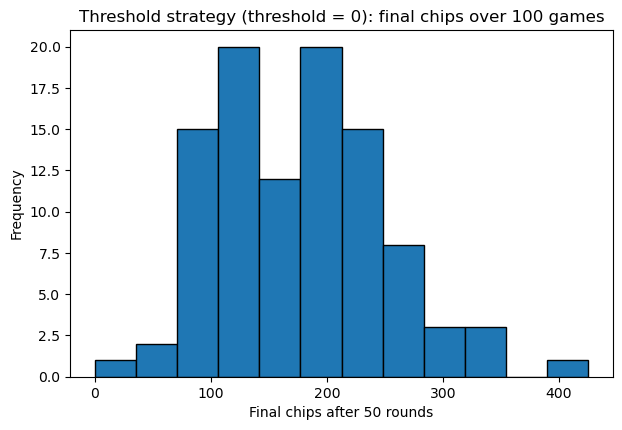

In [17]:
#Histogram
plt.figure(figsize=(7,4.5))
plt.hist(threshold0["final_chips"], bins=12, edgecolor="black")
plt.xlabel("Final chips after 50 rounds")
plt.ylabel("Frequency")
plt.title("Threshold strategy (threshold = 0): final chips over 100 games")
plt.show()

In [19]:
### Scan at least 5 threshold values

thresholds = [-4, -2, 0, 2, 4]
rows = []
all_threshold_results = {}

for t in thresholds:
    out = run_threshold_experiment(   
        threshold=t,
        games=100,
        rounds_per_game=50,
        starting_chips=200,
        base_bet=10,
        seed=100
    )
    all_threshold_results[t] = out
    rows.append({
        "threshold": t,
        "average_final_chips": out["average_final_chips"],
        "average_winnings_per_round": out["average_winnings_per_round"],
        "std_final_chips": out["std_final_chips"],
        "prob_net_win": out["prob_net_win"],
        "prob_net_loss": out["prob_net_loss"],
        "prob_break_even": out["prob_break_even"],
    })

import pandas as pd
threshold_df = pd.DataFrame(rows).sort_values("threshold")
threshold_df

,threshold,average_final_chips,average_winnings_per_round,std_final_chips,prob_net_win,prob_net_loss,prob_break_even
0,-4,163.55,-0.729,74.397564,0.29,0.68,0.03
1,-2,172.00,-0.560,76.854184,0.30,0.70,0.00
2,0,177.15,-0.457,73.372080,0.36,0.62,0.02
3,2,175.05,-0.499,72.427236,0.32,0.65,0.03
4,4,169.10,-0.618,73.657616,0.33,0.65,0.02


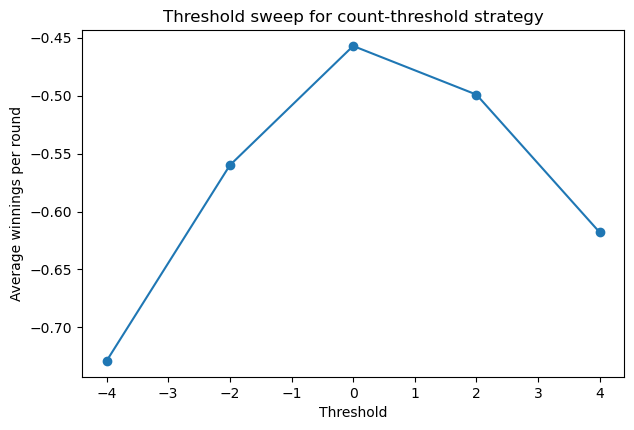

In [20]:
#Scatter
plt.figure(figsize=(7,4.5))
plt.plot(threshold_df["threshold"], threshold_df["average_winnings_per_round"], marker="o")
plt.xlabel("Threshold")
plt.ylabel("Average winnings per round")
plt.title("Threshold sweep for count-threshold strategy")
plt.show()

In [22]:
#Best Threshold
best_row = threshold_df.sort_values("average_winnings_per_round", ascending=False).iloc[0]
best_row

threshold                       0.00000
average_final_chips           177.15000
average_winnings_per_round     -0.45700
std_final_chips                73.37208
prob_net_win                    0.36000
prob_net_loss                   0.62000
prob_break_even                 0.02000
Name: 2, dtype: float64

In [24]:
#New Strat
import pandas as pd

basic = run_basic_strategy_experiment(
    games=100,
    rounds_per_game=50,
    starting_chips=200,
    base_bet=10,
    seed=100
)

comparison_df = pd.DataFrame([
    {
        "strategy": "Count threshold (0)",
        "average_final_chips": threshold0["average_final_chips"],
        "average_winnings_per_round": threshold0["average_winnings_per_round"],
        "std_final_chips": threshold0["std_final_chips"],
        "prob_net_win": threshold0["prob_net_win"],
        "prob_net_loss": threshold0["prob_net_loss"],
    },
    {
        "strategy": "Basic strategy",
        "average_final_chips": basic["average_final_chips"],
        "average_winnings_per_round": basic["average_winnings_per_round"],
        "std_final_chips": basic["std_final_chips"],
        "prob_net_win": basic["prob_net_win"],
        "prob_net_loss": basic["prob_net_loss"],
    }
])

comparison_df

,strategy,average_final_chips,average_winnings_per_round,std_final_chips,prob_net_win,prob_net_loss
0,Count threshold (0),177.15,-0.457,73.372080,0.36,0.62
1,Basic strategy,184.25,-0.315,60.379168,0.36,0.62
